# Lab 2: 10-Year CHD Risk - Framingham Heart Study

Logistic regression modeling 10-year coronary heart disease (CHD) risk from established risk factors (age, blood pressure, cholesterol, smoking, diabetes), using the Framingham Heart Study teaching dataset. 

In [2]:
# Libraries 
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [3]:
# Load data - see data/raw/lab2-epi-framingham/SOURCE.md for details
url = "https://raw.githubusercontent.com/GauravPadawe/Framingham-Heart-Study/master/framingham.csv"
fram = pd.read_csv(url)

# Check
print(fram.shape)
fram.head()
missing_counts = fram.isnull().sum()
print(missing_counts)

(4240, 16)
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


## Handling Missing Data

Several variables have missing values (`glucose`: 388, `education`: 105, `BPMeds`: 53, `totChol`: 50, `cigsPerDay`: 29, `BMI`:19, `heartRate`: 1). Since only 13.7% of rows have any missing value and the data are evenly distributed, I dropped incomplete rows via complete-case analysis (dropping missing value rows) rather than imputation (estimation). Worth noting as a limitation.

In [4]:
print(f"Rows with at least one missing value: {fram.isna().any(axis=1).sum()} of {len(fram)}")

# Complete Case Analysis
fram_clean = fram.dropna()
print(f"Shape after dropping missing values: {fram_clean.shape}")

Rows with at least one missing value: 582 of 4240
Shape after dropping missing values: (3658, 16)


## Logistic Regression Model
Predicting 10-year CHD risk from five established risk factors: age, systolic blood pressure, total cholesterol, current smoking status, and diabetes. Logistic regression is a logical choice because the outcome (`TenYearCHD`) is binary (0/1). Linear regression is not appropriate for a binary outcome. 

In [5]:
# Predictors and Outcome
predictors = ['age', 'sysBP', 'totChol', 'currentSmoker', 'diabetes']
X = fram_clean[predictors]
X = sm.add_constant(X) # intercept term
y = fram_clean['TenYearCHD']

# Fit logisitc regression model
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.385296
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 3658
Model:                          Logit   Df Residuals:                     3652
Method:                           MLE   Df Model:                            5
Date:                Thu, 10 Sep 2026   Pseudo R-squ.:                 0.09687
Time:                        17:42:09   Log-Likelihood:                -1409.4
converged:                       True   LL-Null:                       -1560.6
Covariance Type:            nonrobust   LLR p-value:                 3.112e-63
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -8.0016      0.441    -18.162      0.000      -8.865      -7.138
age               0.

### At a glance: 
age, systolic BP, current smoking, and diabetes are all significant predictors (p < 0.001, except diabetes at p =0.001), but total cholesterol is not (p = 0.206) in this model. 

## Odds Ratios

Converting log-odds coefficients to odds ratios for interpretability. An odds ratio above 1 means the predictor increases CHD odds where below means it decreases them.

In [6]:
# Exponentiate coefficients and their confidence intervals to get odds ratio
odds_ratio = np.exp(model.params)
conf_int = np.exp(model.conf_int())
conf_int.columns = ['2.5%', '97.5%']

results_table = pd.concat([odds_ratio, conf_int], axis=1)
results_table.columns = ['Odds Ratio', '2.5%', '97.5%']
results_table['p-value'] = model.pvalues
print(results_table.round(3))

               Odds Ratio   2.5%  97.5%  p-value
const               0.000  0.000  0.001    0.000
age                 1.068  1.054  1.081    0.000
sysBP               1.017  1.013  1.021    0.000
totChol             1.001  0.999  1.004    0.206
currentSmoker       1.673  1.374  2.038    0.000
diabetes            2.086  1.333  3.263    0.001


## Visualization: Predicted CHD Risk by Age and Smoking Status

Utilizes the fitted model to plot predicted 10-year CHD risk across the age range, comparing current smokers vs. non-smokers. Blood pressure and cholesterol are held at the sample mean, and diabetes at 0 (meaning non-diabetic), so the plot isolates the effect of age and smoking status specifically.

In [9]:
# Build a range of ages to predict across, holding other predictors at representative values so the plot isolates age and smoking status
age_range = np.arange(fram_clean['age'].min(), fram_clean['age'].max() + 1)
mean_sysBP = fram_clean['sysBP'].mean()
mean_totChol = fram_clean['totChol'].mean()

pred_smoker = pd.DataFrame({
    'const':1,
    'age':age_range,
    'sysBP':mean_sysBP,
    'totChol':mean_totChol,
    'currentSmoker':1,
    'diabetes':0
})

pred_nonsmoker = pred_smoker.copy()
pred_nonsmoker['currentSmoker'] = 0

# Aligning column order to match X
pred_smoker = pred_smoker[X.columns]
pred_nonsmoker = pred_nonsmoker[X.columns]
risk_smoker = model.predict(pred_smoker)
risk_nonsmoker = model.predict(pred_nonsmoker)

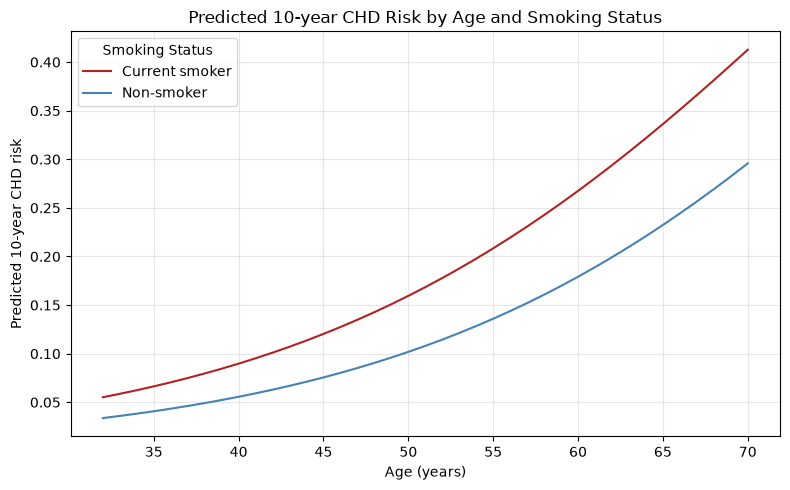

In [11]:
plt.figure(figsize=(8,5))
plt.plot(age_range, risk_smoker, label='Current smoker', color='firebrick')
plt.plot(age_range, risk_nonsmoker, label='Non-smoker', color='steelblue')
plt.xlabel('Age (years)')
plt.ylabel('Predicted 10-year CHD risk')
plt.title('Predicted 10-year CHD Risk by Age and Smoking Status')
plt.legend(title='Smoking Status')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretation:
Based on the results of the logistic regression and the odds ratio, I chose to represent smoking status in a graph to show the risk of smoking and CHD across the age span. The odds ratio was 1.67x for smoking and 1.07x for age, making them strong predictors. Despite smoking status, age seemed to be the stronger predictor of developing CHD. The smokers had a significantly higher risk as well, but smoking alone was not the biggest contributor to CHD. 